In [25]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.special as ss
import pandas as pd
from scipy.stats import binom
import plotly.graph_objects as go
from scipy.special import gamma, beta,digamma,comb
import scipy.optimize as so
from scipy.stats import zipf,gamma

from matplotlib.lines import Line2D

# Constant-Weight Code
The search through continous r is too approximative, we therefore brut force the search for possible optimal values (N,A). The brut force works only for the noisless case. We search the minimum N,A s.t. W is represented. These will be N_start,A_start and then it remains to increase N while decreasing A and find the first pair for which the W constraint is satisfied. Once the following pair is found, N and A are again increased and decreased repectively and so on until reaching A=1. We then compute the beta cutoff by imposing equality between two (N,A) pairs. 

0) Find N_start,A_start using the continous r approximation
1) Search other possible pairs
2) Compute beta cutt off
3) Plot the function (r,beta) for CWC
4) Plot the function (r,beta) of the BSC constraint 


In [7]:
## General Settings
W=int(ss.binom(20,10)) # beautiful W to avoid border effects.

## Search Starting N,A points

In [8]:
## Solve Constant Weight Code with Beta factor=1
## Usueful to determine the starting optimal N,A
def entropyR(r):
    return -(r*np.log(r))-((1-r)*np.log(1-r))

def entropy_2_vecotr(r):
    r = np.asarray(r, dtype=float)
    H = np.zeros_like(r)
    valid = (r > 0) & (r < 1)
    H[valid] = -r[valid] * np.log2(r[valid]) - (1 - r[valid]) * np.log2(1 - r[valid])
    return H

def findOptimalCWC(W,r,beta_fac): # r=N/A
    Hr=entropyR(r)
    Cost=(1+beta_fac*r)*(np.log(W)/Hr) # formula 6 in "Minimizing Costs of Communication with rdm constant weight code"
    idx_r_optim=np.argmin(Cost)
    r_optim=r[idx_r_optim]
    N_optim=np.log(W)/entropyR(r_optim)  # formula 6
    N_fin=int(np.ceil(N_optim)+1)
    a_fin=int(np.ceil(N_fin*r_optim))
    # If doesn't satisfy the constraints, double check
    if ss.binom(N_fin,a_fin)<W:
        finish_func=0 # Bool indicating if the problem is solved
        print('---False Found N,A:',N_fin,a_fin,'/ Binomial :', ss.binom(N_fin,a_fin), ' < W:',W)
        for a2 in range(a_fin,N_fin+1):
            if ss.binom(N_fin,a2)>=W and finish_func==0:
                print('Problem Solved via different A')
                finish_func=1
                a_fin=a2
                print('---Solution Found N,A:',N_fin,a_fin,'/ Binomial :', ss.binom(N_fin,a_fin), ' >= W:',W)
        if finish_func==0:
            for N2 in range(N_fin+1,N_fin+3): # search around N, N+1 and N+2 just to be sure 
                for a2 in range(0,N2):
                    if ss.binom(N2,a2)>=W and finish_func==0:
                        print('Problem Solved via different N & A')
                        finish_func=1
                        a_fin=a2
                        N_fin=N2
                        print('---Solution Found N,A:',N_fin,a_fin,'/ Binomial :', ss.binom(N_fin,a_fin), ' >= W:',W)
    Cost_fin=beta_fac*a_fin+N_fin
    # Check that the cost is indeed smaller here (error due to log and rounding close to the optimal point)
    if Cost_fin-Cost[idx_r_optim]>0.1:
        print('---Warning: Cost is higher than expected')
        print(" Cost:",Cost_fin," vs Expected:",Cost[idx_r_optim])

    return a_fin,N_fin,Cost_fin,Cost

In [9]:
## Point 0: Solve the starting N,A optimal points
ratio_NA=np.linspace(0.01,0.99,5000)
beta=1
A_cwc,N_cwc,Cost_cwc,Costall_cwc=findOptimalCWC(W,ratio_NA,beta)

---False Found N,A: 20 8 / Binomial : 125970.0  < W: 184756
Problem Solved via different A
---Solution Found N,A: 20 10 / Binomial : 184756.0  >= W: 184756
---Warning: Cost is higher than expected
 Cost: 30  vs Expected: 25.20052693645055


## Search all pairs N,A and beta_cutoff

In [12]:
## Search for other N,A pairs that satisfy the constraints, starting from the optimal point found above

def Search_other_options(W,N_start,A_start,facotr_time_search):
    # the second pair is sometimes tricky but should always be with N+1 because can jumpt to A-1 or A-2 (example for W=48620)
    bool_second_pair=0
    A_second_pair=0
    N_second_pair=0
    for A in range(A_start-1,0,-1):
        if ss.binom(N_start+1,A)>=W:
            A_second_pair=A
            N_second_pair=N_start+1
            print('----Multiple Second Solution :',N_start+1,A,'/ Binomial :', ss.binom(N_start+1,A), ' >= W:',W)

    diff_A=A_start-A_second_pair
    sz_sol=A_start-diff_A+1
    all_pairs=np.zeros((sz_sol,2))
    bool_found=np.zeros(sz_sol)
    all_pairs[0,:]=[N_start,A_start]
    all_pairs[1,:]=[N_second_pair,A_second_pair]
    all_pairs[-1,:]=[W,1]
    bool_found[0]=1
    bool_found[1]=1
    bool_found[-1]=1
    # The rest is more trivial search
    for i,A in enumerate(range(A_second_pair,1,-1)):
        print('Searching for A:',A)
        #print('bool found:',bool_found)
        for N in range(N_start,facotr_time_search*N_start):
            if bool_found[i+1]==0:
                if ss.binom(N,A)>=W:
                    bool_found[i+1]=1
                    all_pairs[i+1]= [N,A]
                    print('Solution Found N,A:',N,A,'/ Binomial :', ss.binom(N,A), ' >= W:',W)
    return all_pairs,bool_found

def All_beta_cuttof(all_pairs_NA):
    A_length=all_pairs_NA.shape[0]
    all_beta_co=np.zeros(A_length-1)
    for i in range(0,A_length-1):
        N_0=all_pairs_NA[i,0]
        N_1=all_pairs_NA[i+1,0]
        diff_betas=all_pairs_NA[i,1]-all_pairs_NA[i+1,1]
        all_beta_co[i]= (N_1-N_0)/(diff_betas)
    return all_beta_co

def Obtain_r_values_CWC(all_pairs_NA):
    A_length=all_pairs_NA.shape[0]
    r_vals=np.zeros(A_length)
    for i in range(0,A_length):
        r_vals[i]=all_pairs_NA[i,1]/all_pairs_NA[i,0]
    return r_vals

def rate_CWC_no_noise(all_pairs_NA):
    all_rs=Obtain_r_values_CWC(all_pairs_NA)
    all_N=all_pairs_NA[:,0]
    all_rates=np.zeros_like(all_rs)
    used_rate=np.zeros_like(all_rs)
    for i in range(len(all_rs)):
        all_rates[i]=(1/all_N[i])*np.log2(1/all_rs[i])
        used_rate[i]=(1/all_N[i])*np.log2(W)
    return all_rates,used_rate

In [13]:
Nbr_points_search=10000 # increase this if can't find the last pairs
all_pairs_NA,bool_found_NA=Search_other_options(W,N_cwc,A_cwc,facotr_time_search=Nbr_points_search*N_cwc)
if bool_found_NA.sum()==len(bool_found_NA): # verify all pairs have been found
    print('All pairs N,A found',bool_found_NA)
all_beta_co=All_beta_cuttof(all_pairs_NA)

----Multiple Second Solution : 21 9 / Binomial : 293930.0  >= W: 184756
----Multiple Second Solution : 21 8 / Binomial : 203490.0  >= W: 184756
Searching for A: 8
Searching for A: 7
Solution Found N,A: 23 7 / Binomial : 245157.0  >= W: 184756
Searching for A: 6
Solution Found N,A: 26 6 / Binomial : 230230.0  >= W: 184756
Searching for A: 5
Solution Found N,A: 32 5 / Binomial : 201376.0  >= W: 184756
Searching for A: 4
Solution Found N,A: 48 4 / Binomial : 194580.0  >= W: 184756
Searching for A: 3
Solution Found N,A: 105 3 / Binomial : 187460.0  >= W: 184756
Searching for A: 2
Solution Found N,A: 609 2 / Binomial : 185136.0  >= W: 184756
All pairs N,A found [1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [14]:
## Only if W not tooo big
# Plots the cost curves of all the pairs to verify the beta cutoffs
if W < 10000:
    beta_final=int(all_pairs_NA[-1,0]-all_pairs_NA[-2,0])
    add_bet=int(0.001*beta_final)
    i_bet=np.linspace(0,beta_final+add_bet,beta_final+add_bet+1)
    curve_all_costs=np.zeros((len(i_bet),len(all_pairs_NA)))
    for i in range(len(all_pairs_NA)): 
        print('Calculating cost curve for A=',all_pairs_NA[i,1], ' with N=',all_pairs_NA[i,0]) 
        curve_all_costs[:,i]=i_bet*all_pairs_NA[i,1]+all_pairs_NA[i,0]
    for i in range(len(all_pairs_NA)):      
        plt.plot(i_bet,curve_all_costs[:,i],label=i)
    plt.legend()
    plt.xlabel('Beta')
    plt.ylabel('Cost')
    plt.ylim(0,200)
    plt.xlim(0,20)
    


### Plots r,beta curve for the N,A pairs

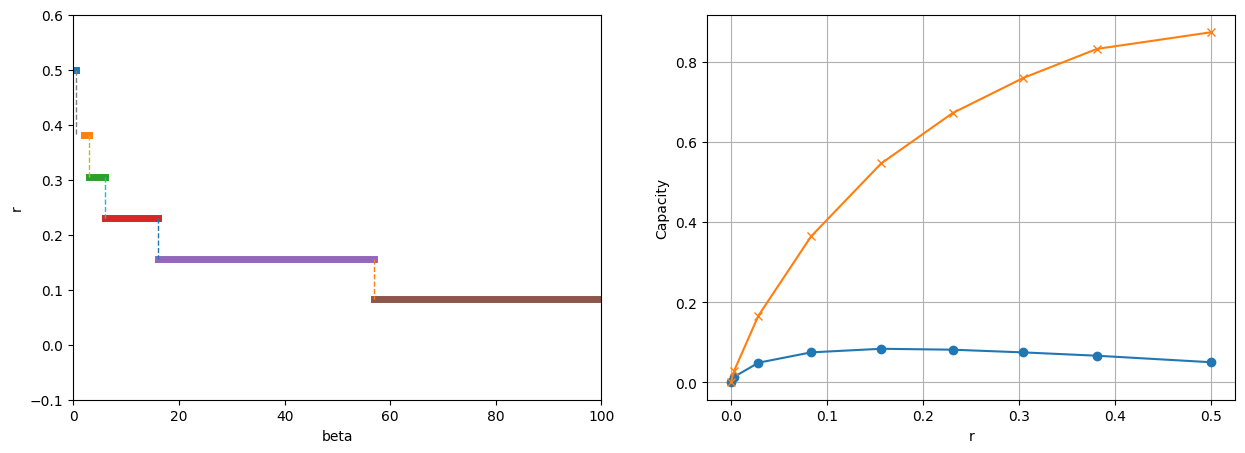

In [16]:
# Plots r, beta curves for the piecewise constant function
r_vals = Obtain_r_values_CWC(all_pairs_NA)

# Segments as piecewise constant functions where r is constant between beta0 and beta1
segments = []
segments.append((0, all_beta_co[0], r_vals[0]))
for i in range(1,len(all_beta_co)-1): 
    segments.append((all_beta_co[i], all_beta_co[i+1], r_vals[i]))
    
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

for b0, b1, r in segments:
    ax1.plot([b0, b1], [r, r], linewidth=5)
# draw dashed jump lines (GPT generated)
for i in range(len(segments) - 1):
    _, x_jump, r1 = segments[i]
    _, _, r2 = segments[i + 1]
    ax1.plot([x_jump, x_jump], [r1, r2], '--', linewidth=1)

ax1.set_ylim(-0.1, 0.6)
ax1.set_xlim(-0.1, 100)
ax1.set_xlabel("beta")
ax1.set_ylabel("r")

cap_values,CWC_used_rate=rate_CWC_no_noise(all_pairs_NA)
ax2.plot(r_vals,cap_values, marker='o')
ax2.plot(r_vals,CWC_used_rate, marker='x')

ax2.set_xlabel("r")
ax2.set_ylabel("Capacity")

plt.grid(True)
plt.show()


# BSC channel

In [18]:
def BSC_r_beta(beta,p): # Eq. 71
    factor=1/(1-2*p)
    r_interm=factor*(1/(np.exp(beta*factor)+1)-p)
    if p==0:
        return r_interm
    beta_max = 1/factor * np.log(1/p - 1) # Eq. 72

    r = np.where(       # Function depending on beta values
        beta == 0,
        0.5,
        np.where(
            beta < beta_max,
            r_interm,
            0.0
        )
    )
    
    return r
    
def BSC_Cap_cost(Gamma,p,rho_0,rho_1): # Eq. 73
    Gamma_max=(rho_0+rho_1)/2 # Eq. 74
    gamma_normal=(Gamma-rho_0)/(rho_1-rho_0)
    q_r=p+gamma_normal*(1-2*p)

    Cap_unconst=1-entropy_2_vecotr(p)
    Cap_constraint=entropy_2_vecotr(q_r)-entropy_2_vecotr(p)
    Cap = np.where(       # Function depending on beta values
        Gamma <= 0,
        0,
        np.where(
            Gamma < Gamma_max,
            Cap_constraint,
            Cap_unconst
        )
    )
    return Cap


### Plot for BSC

/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56410/3829564231.py:40: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(frameon=False, fontsize=13, loc="best")


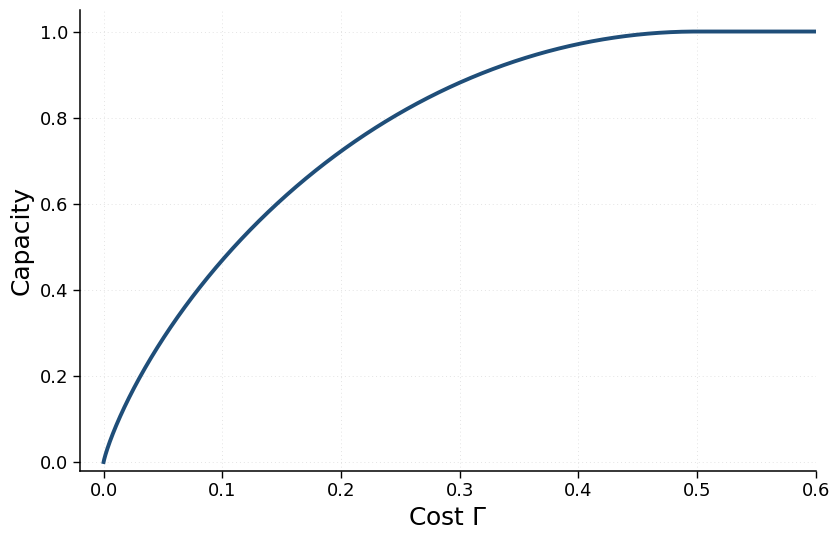

In [19]:
p_test = 0
nbr_pts = 10000

rho_0 = 0
rho_1 = 1

gamma_continous = np.linspace(0, 1, nbr_pts)
cap_bsc = BSC_Cap_cost(gamma_continous, p_test, rho_0, rho_1)
cap_bsc2 = BSC_Cap_cost(gamma_continous, 0.1, rho_0, rho_1)

fig, ax = plt.subplots(figsize=(8.5, 5.5))

ax.plot(
    gamma_continous,
    cap_bsc,
    linewidth=2.8,
    color="#1f4e79",
)

# Labels
ax.set_xlabel(r"Cost $\Gamma$", fontsize=18)
ax.set_ylabel(r"Capacity", fontsize=18)

# Limits
ax.set_xlim(-0.02, 0.6)
ax.set_ylim(bottom=-0.02)

# Minimalist style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.1)
ax.spines["bottom"].set_linewidth(1.1)

ax.tick_params(axis='both', which='major', labelsize=13, length=5, width=1)

# Light grid
ax.grid(True, linestyle=(0, (1, 3)), linewidth=0.7, alpha=0.35)

# Legend
ax.legend(frameon=False, fontsize=13, loc="best")

plt.tight_layout()
plt.show()

# Different Input Codebook size 

Now for figure 8, we want to plot the later curve but for different size of input codebook. 

### Plots r,beta for different W

In [20]:
W1=int(ss.binom(12,6)) # we take half because it maximise the numbers of beta_cutoff
W2=int(ss.binom(64,32))

In [21]:
# Constant CWC algo
ratio_NA=np.linspace(0.01,0.99,5000)
beta=1 # beta for the 1st pair of N,A
Nbr_points_search=1000 # How far away the brut force search for the other N,A pairs
Nbr_Points_deleted_W2=3 # Remove some of the pairs since they are anyway too far away
# BSC constants
p_bsc=0 # BSC noise level 
nbr_pts_bsc=10000 # number of points when plotting the BSC curve
rho_0_bsc=0
rho_1_bsc=1

# Plots
color_W1='blue'
color_W2='orange'

In [22]:
# For W1:
## Point 0: Solve the starting N,A optimal points
A1_cwc,N1_cwc,Cost1_cwc,Costall1_cwc=findOptimalCWC(W1,ratio_NA,beta)
## Point 1: Search other pairs
all_pairs_NA_1,bool_found_NA_1=Search_other_options(W1,N1_cwc,A1_cwc,facotr_time_search=Nbr_points_search*N1_cwc)
if bool_found_NA_1.sum()==len(bool_found_NA_1): # verify all pairs have been found
    print('All pairs N,A found',bool_found_NA_1)
## Point 2: Search beta cutoffs
all_beta_co_1=All_beta_cuttof(all_pairs_NA_1)
## Point 3: Save segments for the piecewise constant function
r_vals_1 = [all_pairs_NA_1[i,1]/all_pairs_NA_1[i,0] for i in range(len(all_pairs_NA_1))]
segments_1 = []
segments_1.append((0, all_beta_co_1[0], r_vals_1[0]))
for i in range(1,len(all_beta_co_1)-1): 
    segments_1.append((all_beta_co_1[i], all_beta_co_1[i+1], r_vals_1[i]))
CWC_1_cap_values,CWC_1_used_rate=rate_CWC_no_noise(all_pairs_NA_1)


# For W2:
## Point 0: Solve the starting N,A optimal points
A2_cwc,N2_cwc,Cost2_cwc,Costall2_cwc=findOptimalCWC(W2,ratio_NA,beta)
## Point 1: Search other pairs
all_pairs_NA_2,bool_found_NA_2=Search_other_options(W2,N2_cwc,A2_cwc,facotr_time_search=Nbr_points_search*N2_cwc)
if bool_found_NA_2.sum()==len(bool_found_NA_2): # verify all pairs have been found
    print('All pairs N,A found',bool_found_NA_2)
## Point 2: Search beta cutoffs
all_beta_co_2=All_beta_cuttof(all_pairs_NA_2)
## Point 3: Save segments for the piecewise constant function
r_vals_2 = [all_pairs_NA_2[i,1]/all_pairs_NA_2[i,0] for i in range(len(all_pairs_NA_2)-Nbr_Points_deleted_W2)]
segments_2 = []
segments_2.append((0, all_beta_co_2[0], r_vals_2[0]))
for i in range(1,len(all_beta_co_2)-1-Nbr_Points_deleted_W2): 
    segments_2.append((all_beta_co_2[i], all_beta_co_2[i+1], r_vals_2[i]))
CWC_2_cap_values,CWC_2_used_rate=rate_CWC_no_noise(all_pairs_NA_2)


# For the BSC: (choosing between W1 or W2 will just give us a limit on the value of beta we want to plot)
beta_continou_bsc=np.linspace(0,all_beta_co_1[-1],nbr_pts_bsc)
r_bsc=BSC_r_beta(beta_continou_bsc,p_bsc)
gamma_continous_bsc=np.linspace(0,1,nbr_pts)
cap_bsc=BSC_Cap_cost(gamma_continous_bsc,p_bsc,rho_0_bsc,rho_1_bsc)



---False Found N,A: 12 5 / Binomial : 792.0  < W: 924
Problem Solved via different A
---Solution Found N,A: 12 6 / Binomial : 924.0  >= W: 924
---Warning: Cost is higher than expected
 Cost: 18  vs Expected: 14.190657531597237
----Multiple Second Solution : 13 5 / Binomial : 1287.0  >= W: 924
Searching for A: 5
Searching for A: 4
Solution Found N,A: 14 4 / Binomial : 1001.0  >= W: 924
Searching for A: 3
Solution Found N,A: 19 3 / Binomial : 969.0  >= W: 924
Searching for A: 2
Solution Found N,A: 44 2 / Binomial : 946.0  >= W: 924
All pairs N,A found [1. 1. 1. 1. 1. 1.]
---False Found N,A: 65 25 / Binomial : 6.516876742211318e+17  < W: 1832624140942590464
Problem Solved via different A
---Solution Found N,A: 65 28 / Binomial : 1.965407271460557e+18  >= W: 1832624140942590464
---Warning: Cost is higher than expected
 Cost: 93  vs Expected: 87.38829602664455
----Multiple Second Solution : 66 27 / Binomial : 2.45079125348118e+18  >= W: 1832624140942590464
Searching for A: 27
Searching for 

/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56410/2652572432.py:50: RuntimeWarning: invalid value encountered in scalar divide
  r_vals[i]=all_pairs_NA[i,1]/all_pairs_NA[i,0]
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56410/2652572432.py:59: RuntimeWarning: divide by zero encountered in scalar divide
  all_rates[i]=(1/all_N[i])*np.log2(1/all_rs[i])
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56410/2652572432.py:60: RuntimeWarning: divide by zero encountered in scalar divide
  used_rate[i]=(1/all_N[i])*np.log2(W)
/var/folders/bq/clcmq2815517pyz5frwskkqc0000gn/T/ipykernel_56410/403747052.py:3: RuntimeWarning: overflow encountered in exp
  r_interm=factor*(1/(np.exp(beta*factor)+1)-p)


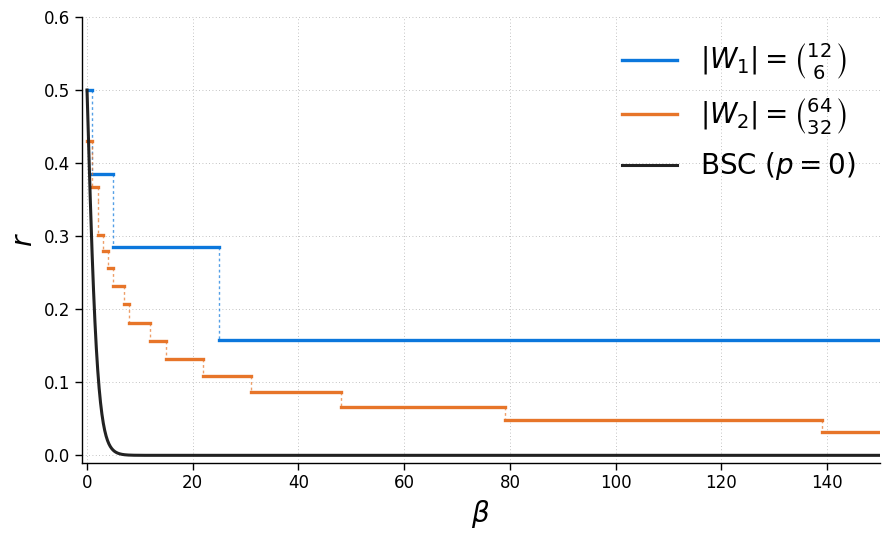

In [26]:
## AI more elegant plot


# Elegant minimalist colors
color_W1 = "#0b77dc"   # deep blue
color_W2 = "#e77529"   # warm orange-brown
color_BSC = "#222222"  # soft black

fig, ax = plt.subplots(figsize=(9, 5.5))

# -------------------------
# W1 piecewise-constant
# -------------------------
for b0, b1, r in segments_1:
    ax.plot([b0, b1], [r, r], linewidth=2.4, color=color_W1)
for i in range(len(segments_1) - 1):
    _, x_jump, r1 = segments_1[i]
    _, _, r2 = segments_1[i + 1]
    ax.plot([x_jump, x_jump], [r1, r2],
            linestyle=(0, (2, 2)), linewidth=1.0, color=color_W1, alpha=0.7)

# -------------------------
# W2 piecewise-constant
# -------------------------
for b0, b1, r in segments_2:
    ax.plot([b0, b1], [r, r], linewidth=2.4, color=color_W2)
for i in range(len(segments_2) - 1):
    _, x_jump, r1 = segments_2[i]
    _, _, r2 = segments_2[i + 1]
    ax.plot([x_jump, x_jump], [r1, r2],
            linestyle=(0, (2, 2)), linewidth=1.0, color=color_W2, alpha=0.7)

# -------------------------
# BSC continuous curve
# -------------------------
ax.plot(beta_continou_bsc, r_bsc, linewidth=2.2, color=color_BSC,
        label=fr"BSC ($p={p_bsc}$)")

# Limits
ax.set_ylim(-0.01, 0.6)
ax.set_xlim(-1, 150)

# Labels
ax.set_xlabel(r"$\beta$", fontsize=20)
ax.set_ylabel(r"$r$", fontsize=20)

# Minimalist style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_linewidth(1.0)
ax.spines["bottom"].set_linewidth(1.0)
ax.tick_params(axis='both', which='major', labelsize=12, length=5, width=1)

# Light grid
ax.grid(True, linestyle=(0, (1, 3)), linewidth=0.6, alpha=1)

# Custom legend so W1 and W2 appear once 12,6
legend_handles = [
    Line2D([0], [0], color=color_W1, lw=2.4, label=r"$|W_1|=\binom{12}{6}$"),
    Line2D([0], [0], color=color_W2, lw=2.4, label=r"$|W_2|=\binom{64}{32}$"),
    Line2D([0], [0], color=color_BSC, lw=2.2, label=fr"BSC ($p={p_bsc}$)")
]

ax.legend(handles=legend_handles, frameon=False, fontsize=20, loc="upper right")

plt.tight_layout()
plt.show()